# Response function of a moving average

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/response_function_moving_avg.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-26*

## Learning objectives

- Apply a 3-point moving-average filter (`[1, 1, 1]`) in time space with `scipy.signal.lfilter` and `filtfilt`, and see how forward-only filtering introduces a phase shift.
- Compute the squared response function from theory and from the ratio of output to input power spectra, and confirm they agree.
- See that repeated smoothing moves power to lower frequencies, exactly as expected.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as sig

# Figure defaults for this notebook.
plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (6.0, 4.0)

LW = 2
LFS = 6

## Make a simple input signal

Use a length-29 array of zeros with two consecutive 1s in the middle. The narrow pulse keeps the response easy to see.

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]


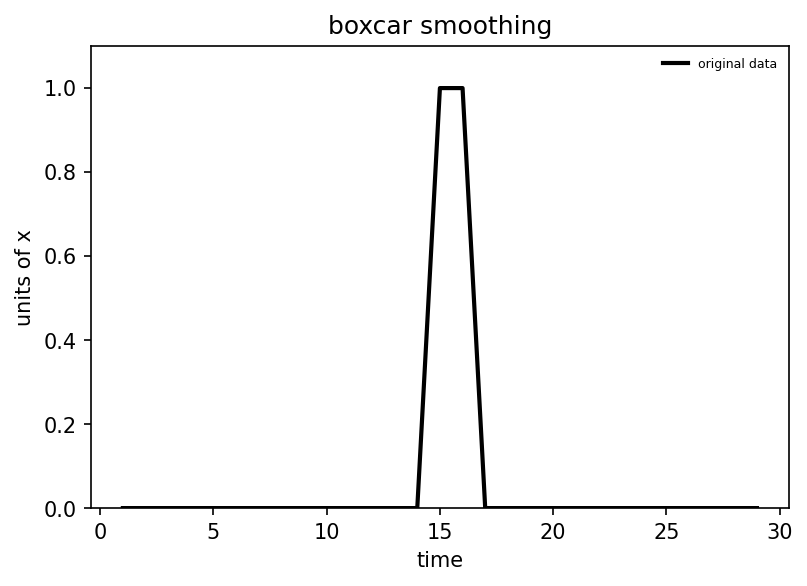

In [2]:
t = np.arange(1, 30)
x = np.zeros(t.size)
x[t.size // 2 : t.size // 2 + 2] = 1.0
print(x)

plt.figure()
plt.title("boxcar smoothing")
plt.plot(t, x, "-k", linewidth=LW, label="original data")
plt.ylim(0, 1.1)
plt.xlabel("time")
plt.ylabel("units of x")
plt.legend(frameon=False, fontsize=LFS)
plt.show()

## Apply the moving average in time

The `[1, 1, 1]` filter (normalized by 3) is the 3-point moving average. `sig.lfilter` applies it as a left-centred (causal) filter, which introduces a phase lag.

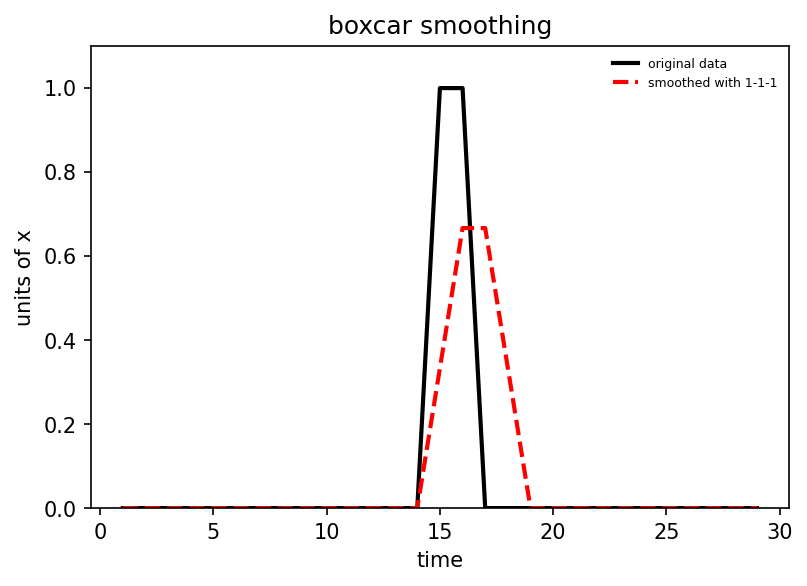

In [3]:
g = [1.0, 1.0, 1.0]

y1 = sig.lfilter(g, np.sum(g), x)

plt.figure()
plt.title("boxcar smoothing")
plt.plot(t, x, "-k", linewidth=LW, label="original data")
plt.plot(t, y1, "--r", linewidth=LW, label="smoothed with 1-1-1")
plt.ylim(0, 1.1)
plt.xlabel("time")
plt.ylabel("units of x")
plt.legend(frameon=False, fontsize=LFS)
plt.show()

The smoothed signal is shifted to the right. That phase shift is a property of `sig.lfilter` (see [the docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.lfilter.html)).

### Forward–backward via `filtfilt`

`sig.filtfilt` runs the filter forward then backward, cancelling the phase shift at the cost of a squared response.

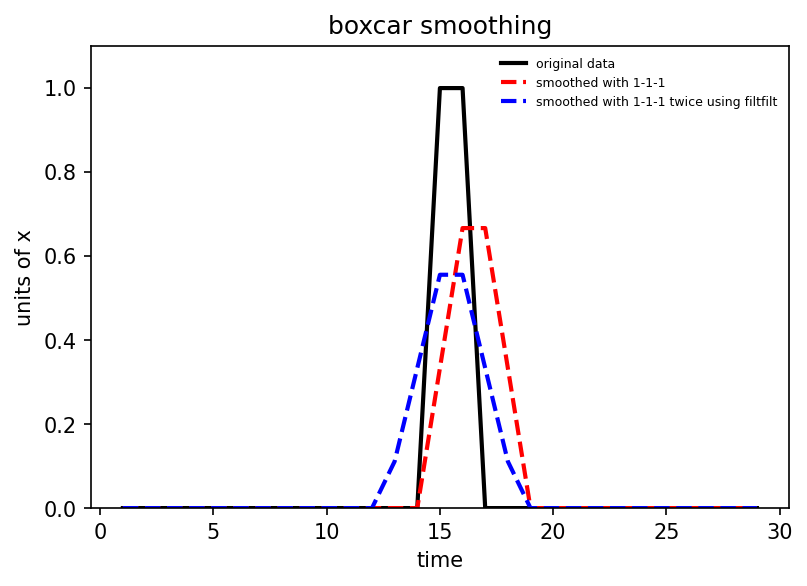

In [4]:
y2 = sig.filtfilt(g, np.sum(g), x)

plt.figure()
plt.title("boxcar smoothing")
plt.plot(t, x, "-k", linewidth=LW, label="original data")
plt.plot(t, y1, "--r", linewidth=LW, label="smoothed with 1-1-1")
plt.plot(t, y2, "--b", linewidth=LW, label="smoothed with 1-1-1 twice using filtfilt")
plt.legend(frameon=False, fontsize=LFS)
plt.ylim(0, 1.1)
plt.xlabel("time")
plt.ylabel("units of x")
plt.show()

To make the point that `filtfilt` is doing something different from just calling `lfilter` twice forward, apply `lfilter` to `y1` again — the result is even more phase-shifted than before.

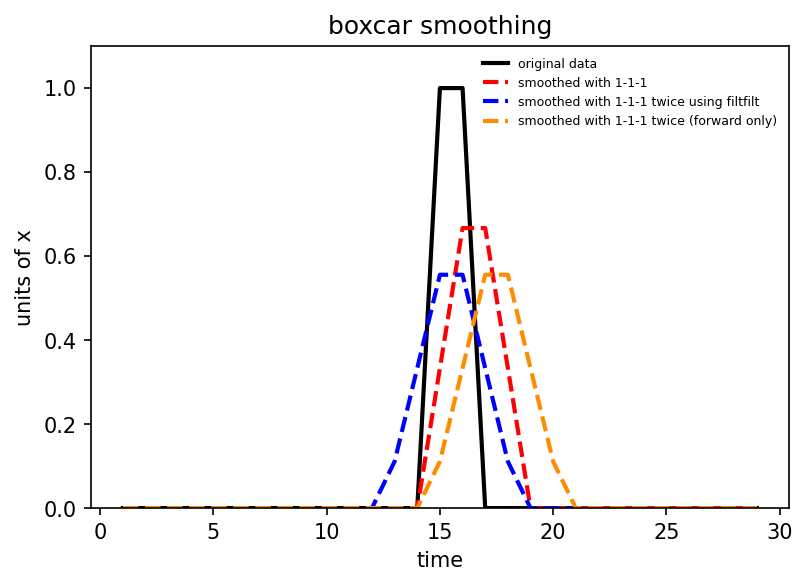

In [5]:
y22 = sig.lfilter(g, np.sum(g), y1)

plt.figure()
plt.title("boxcar smoothing")
plt.plot(t, x, "-k", linewidth=LW, label="original data")
plt.plot(t, y1, "--r", linewidth=LW, label="smoothed with 1-1-1")
plt.plot(t, y2, "--b", linewidth=LW, label="smoothed with 1-1-1 twice using filtfilt")
plt.plot(
    t,
    y22,
    "--",
    color="darkorange",
    linewidth=LW,
    label="smoothed with 1-1-1 twice (forward only)",
)
plt.legend(frameon=False, fontsize=LFS)
plt.ylim(0, 1.1)
plt.xlabel("time")
plt.ylabel("units of x")
plt.show()

Two lessons from the orange curve: know what your software is doing, and forward–backward filtering (`filtfilt`) is the standard way to avoid an accumulating phase lag.

## Response function from data and from theory

Compute the response two ways and compare:

1. **From theory.** The squared response of `[1, 1, 1]/3` is $R^2(f) = \left(\tfrac{1}{3} + \tfrac{2}{3} \cos(2\pi f)\right)^2$.
2. **From data.** Take the ratio of the smoothed power spectrum to the original power spectrum.

In [6]:
Z_x = np.fft.fft(x) / x.size
Z_y1 = np.fft.fft(y1) / y1.size
Z_y2 = np.fft.fft(y2) / y2.size

half = x.size // 2 + 1
Ck2_x = np.abs(Z_x[:half]) ** 2
Ck2_y1 = np.abs(Z_y1[:half]) ** 2
Ck2_y2 = np.abs(Z_y2[:half]) ** 2

freq = np.arange(0, x.size / 2) / float(x.size)

Rg_y1 = 1.0 / 3 + (2.0 / 3) * np.cos(freq * 2.0 * np.pi)
Rg2_y1 = Rg_y1**2
Rg_y2 = Rg_y1**2
Rg2_y2 = Rg_y2**2

### Spectra before vs after filtering

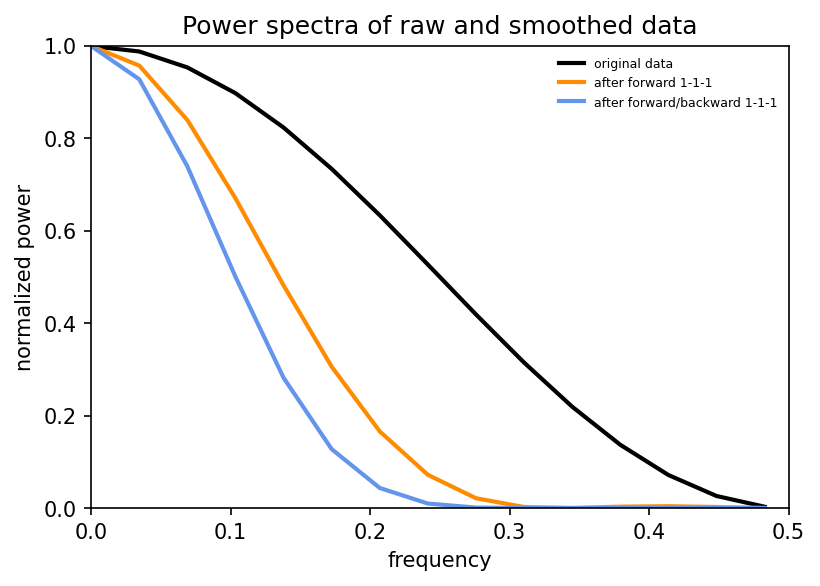

In [7]:
maxval = np.max(Ck2_x)

plt.figure()
plt.title("Power spectra of raw and smoothed data")
plt.plot(freq[: Ck2_x.size], Ck2_x / maxval, "-k", linewidth=LW, label="original data")
plt.plot(
    freq[: Ck2_y1.size],
    Ck2_y1 / maxval,
    "-",
    color="darkorange",
    linewidth=LW,
    label="after forward 1-1-1",
)
plt.plot(
    freq[: Ck2_y2.size],
    Ck2_y2 / maxval,
    "-",
    color="cornflowerblue",
    linewidth=LW,
    label="after forward/backward 1-1-1",
)
plt.legend(fontsize=LFS, frameon=False)
plt.ylim(0, 1)
plt.xlim(0, 0.5)
plt.xlabel("frequency")
plt.ylabel("normalized power")
plt.show()

### Squared response: theory vs measured

The data-derived ratio sits exactly on top of the theoretical curve, and the doubled filter pushes the cutoff to lower frequencies.

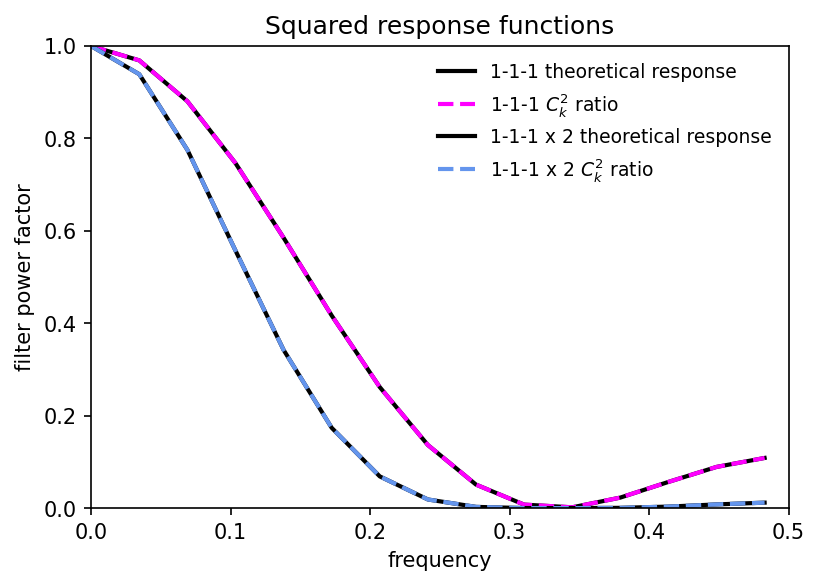

In [8]:
plt.figure()
plt.title("Squared response functions")
plt.plot(
    freq, Rg2_y1[: freq.size], "-k", linewidth=LW, label="1-1-1 theoretical response"
)
plt.plot(
    freq,
    Ck2_y1[: freq.size] / Ck2_x[: freq.size],
    "--",
    color="fuchsia",
    linewidth=LW,
    label=r"1-1-1 $C_k^2$ ratio",
)
plt.plot(
    freq,
    Rg2_y2[: freq.size],
    "-k",
    linewidth=LW,
    label="1-1-1 x 2 theoretical response",
)
plt.plot(
    freq,
    Ck2_y2[: freq.size] / Ck2_x[: freq.size],
    "--",
    color="cornflowerblue",
    linewidth=LW,
    label=r"1-1-1 x 2 $C_k^2$ ratio",
)
plt.ylim(0, 1)
plt.xlim(0, 0.5)
plt.legend(fontsize=LFS * 1.5, frameon=False)
plt.ylabel("filter power factor")
plt.xlabel("frequency")
plt.show()

## Side-by-side view for lecture

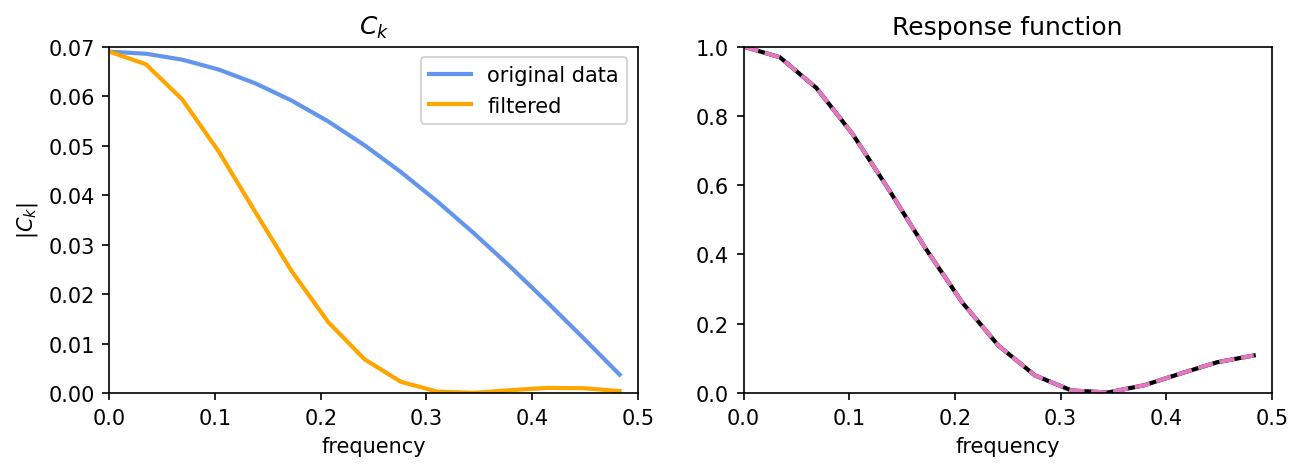

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3))

ax = axs[0]
ax.plot(
    freq,
    np.sqrt(Ck2_x[: freq.size]),
    "-",
    color="cornflowerblue",
    linewidth=LW,
    label="original data",
)
ax.plot(
    freq,
    np.sqrt(Ck2_y2[: freq.size]),
    "-",
    color="orange",
    linewidth=LW,
    label="filtered",
)
ax.set_ylabel(r"$|C_k|$")
ax.set_xlabel("frequency")
ax.set_title(r"$C_k$")
ax.legend()
ax.set_ylim(0, 0.07)
ax.set_xlim(0, 0.5)

ax = axs[1]
ax.plot(freq, Rg_y2[: freq.size], "-k", linewidth=LW, label="response function")
ax.plot(
    freq,
    np.sqrt(Ck2_y2[: freq.size]) / np.sqrt(Ck2_x[: freq.size]),
    "--",
    color="tab:pink",
    linewidth=LW,
    label="response function (data)",
)
ax.set_title("Response function")
ax.set_xlabel("frequency")
ax.set_ylim(0, 1.0)
ax.set_xlim(0, 0.5)

plt.show()

## Take-home points

- A moving average is a convolution; in frequency space it is a multiplication by the filter's response function.
- The `[1, 1, 1]/3` response function is real, and its theoretical formula matches the empirical ratio of output to input power spectra.
- Repeated smoothing (or `filtfilt`) squares the response — sharper roll-off, but still no phase lag if you use `filtfilt`.